# TODO:

*figure out how to mitigate the runTime error where there are whole sin the data, might have to 'fill in' the wholes so that its not apparent it's there 


#welch vs multitaper method


*Add more parameters such as ... 
    mean_values
    std_dev_values
    skewness_values
    kurtoisis_values (possibly for each channel), they do it here --> https://www.kaggle.com/code/yosftag/code-1#*-mean

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import mne
import mne_features
import entropy as ent
import neurokit2 as nk
from scipy.signal import welch
from nolds import lyap_r
import antropy as ant
import joblib

In [2]:
participantsInfo = pd.read_table('./ds004504/participants.tsv')
#Getting all the groups
A_sub = participantsInfo[participantsInfo["Group"] == "A"]["participant_id"].tolist()
C_sub = participantsInfo[participantsInfo["Group"] == "C"]["participant_id"].tolist()
D_sub = participantsInfo[participantsInfo["Group"] == "F"]["participant_id"].tolist()

In [3]:
print(C_sub)

['sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-041', 'sub-042', 'sub-043', 'sub-044', 'sub-045', 'sub-046', 'sub-047', 'sub-048', 'sub-049', 'sub-050', 'sub-051', 'sub-052', 'sub-053', 'sub-054', 'sub-055', 'sub-056', 'sub-057', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-062', 'sub-063', 'sub-064', 'sub-065']


In [5]:
def derivativesPath(sub): # ! I was using the dericatives is the data
    # return f"ds004504/{sub}/eeg/{sub}_task-eyesclosed_eeg.set"
    return f"ds004504/derivatives/{sub}/eeg/{sub}_task-eyesclosed_eeg.set" 

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/Users/admin/neuro-venv/lib/python3.9/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


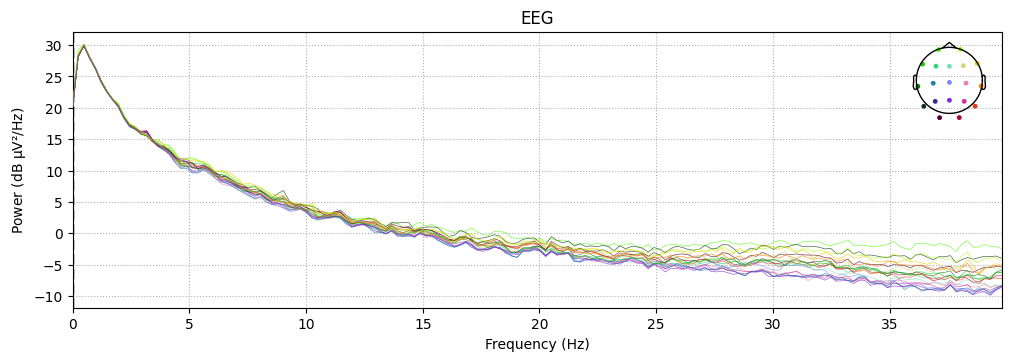

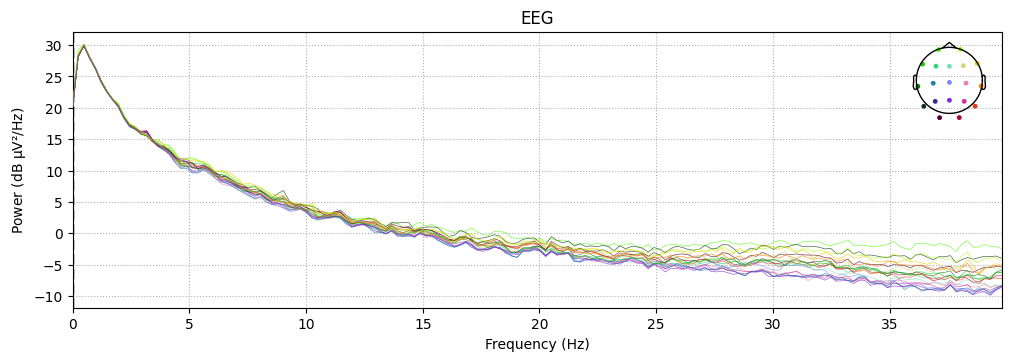

In [6]:
raw_sub = mne.io.read_raw_eeglab(derivativesPath('sub-001'), preload=True)
x = raw_sub.compute_psd(fmax=40)
x.plot()

In [7]:
freq_bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 12),
    "Beta": (12, 30),
}

import pandas as pd
import numpy as np 

#this generates the dataframe persubject
def generate_subject_dataframe(subjects) -> pd.DataFrame:
    """
    Generates a DataFrame where each subject has 19 channels, 
    and each channel has 4 bands (Delta, Theta, Alpha, Beta).
    
    Parameters:
        num_subjects (int): Number of subjects to include in the DataFrame.
    
    Returns:
        pd.DataFrame: A DataFrame with hierarchical indexing for subjects, channels, and bands for each window.
    """
    # subjects = [f"sub-{i:03d}" for i in range(start_sub, end_sub + 1)]  # Format subject IDs as sub-XXX
    channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
    bands = ["Delta", "Theta", "Alpha", "Beta"]
    
    data = []
    for subject in subjects:
        for channel in channels:
            for band, val in freq_bands.items():
                value = np.random.rand()  # Example random value, replace with actual data if needed
                data.append([subject, channel, band, []])
    
    df = pd.DataFrame(data, columns=["Subject", "Channel", "Band", "Window Avg"])

    #the .setIndex is creating a multiIndex DataFrame
    return df.set_index(["Subject", "Channel", "Band"])


    # Example usage:
# df = generate_subject_dataframe(5)  # Generates a DataFrame for 5 subjects
# print(df)

In [8]:


# NUM_SUBJECTS = 2
# # Use the function inside the groups dictionary
# groups = {
#     'Alzeimers': generate_subject_dataframe(A_sub[0:NUM_SUBJECTS]),
#     'Control': generate_subject_dataframe(C_sub[0:NUM_SUBJECTS]),
#     'Dementia': generate_subject_dataframe(D_sub[0:NUM_SUBJECTS]),
# }

# NUM_SUBJECTS = 2
# # Use the function inside the groups dictionary
groups = {
    'Alzeimers': generate_subject_dataframe(A_sub),
    'Control': generate_subject_dataframe(C_sub),
    'Dementia': generate_subject_dataframe(D_sub),
}

# Print the DataFrame for 'Alzeimers'

# WINDOW_LENGTH = 1.5
# STEP_SIZE = .75 #50% sliding window
WINDOW_LENGTH = 3
STEP_SIZE = 1.5

In [9]:
print(A_sub[0:NUM_SUBJECTS])

NameError: name 'NUM_SUBJECTS' is not defined

In [10]:
print(groups['Alzeimers'])
print(groups['Control'])
print(groups['Dementia'])

                      Window Avg
Subject Channel Band            
sub-001 Fp1     Delta         []
                Theta         []
                Alpha         []
                Beta          []
        Fp2     Delta         []
...                          ...
sub-036 Cz      Beta          []
        Pz      Delta         []
                Theta         []
                Alpha         []
                Beta          []

[2736 rows x 1 columns]
                      Window Avg
Subject Channel Band            
sub-037 Fp1     Delta         []
                Theta         []
                Alpha         []
                Beta          []
        Fp2     Delta         []
...                          ...
sub-065 Cz      Beta          []
        Pz      Delta         []
                Theta         []
                Alpha         []
                Beta          []

[2204 rows x 1 columns]
                      Window Avg
Subject Channel Band            
sub-066 Fp1     Delta     

# Testing to see if we are calculating the mean correctly

Not setting metadata
398 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 398 events and 1501 original time points ...
0 bad epochs dropped
Min 0.5, Max 30
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
freqs[0.66622252 0.99933378 1.33244504 1.6655563  1.99866755 2.33177881
 2.66489007 2.99800133 3.33111259 3.66422385 3.99733511]
channel at that freq [[[4.12232713e-07 2.56616555e-07 2.62203676e-07 1.73734328e-07
   1.09290997e-07 6.04140049e-08 3.48651550e-08 3.05786368e-08
   1.55078970e-08 1.24568653e-08 8.96978107e-09]]]
1.2517005531358903e-07
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/Users/admin/neuro-venv/lib/python3.9/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


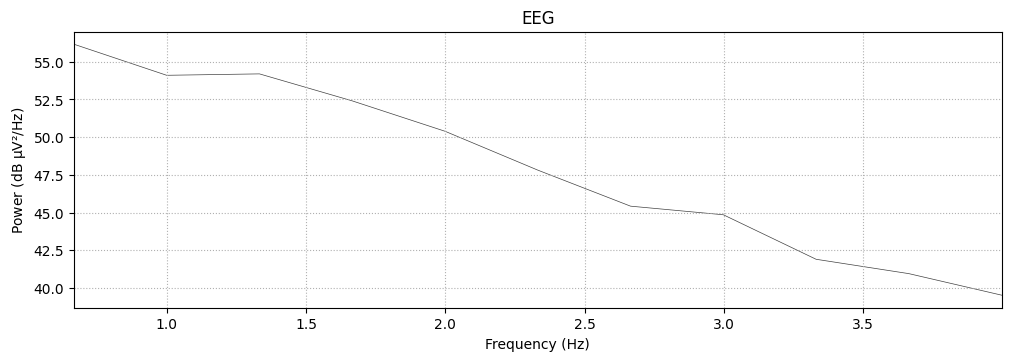

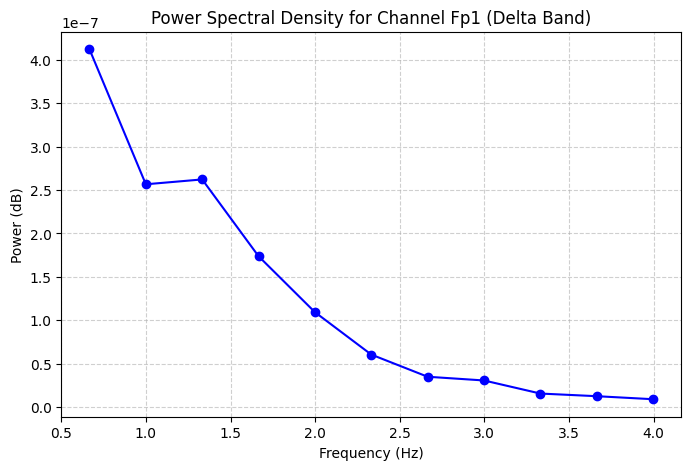

NameError: name 'psds' is not defined

In [12]:
#print(groups['Control'].loc[('sub-037', 'Fp1', 'Delta'), "Window Avg"][0])
raw_sub = mne.io.read_raw_eeglab(derivativesPath('sub-001'), preload=True)
sfreq = raw_sub.info['sfreq']
start_times = np.arange(0, raw_sub.times[-1] - WINDOW_LENGTH, STEP_SIZE) 
events = np.array([
[int(t * sfreq), 0, 1] for t in start_times  # MNE event format
]) 

epochs = mne.Epochs(
    raw_sub, events, event_id=1,
    tmin=0, tmax=WINDOW_LENGTH,
    baseline=None, detrend=1, preload=True, verbose=True
)
epoch = epochs[0]
print(f'Min {freq_bands["Delta"][0]}, Max {freq_bands["Beta"][1]}')
epoch_psd = epoch.compute_psd(fmin=freq_bands["Delta"][0], fmax=freq_bands["Beta"][1], verbose=True) #computing the max PSD between the wave lengths
epoch_psd = epoch.compute_psd(fmin=0.5, fmax=4, verbose=True) #computing the max PSD between the wave lengths
channel_at_freq, freqs = epoch_psd.get_data(picks='Fp1' , fmin=freq_bands["Delta"][0], fmax=freq_bands["Delta"][1], return_freqs=True)

mean_power = channel_at_freq.mean(axis=0)
channel_at_freq_avg = channel_at_freq.mean(axis=-1)
print(f'freqs{freqs}')
print(f'channel at that freq {channel_at_freq}')
print(channel_at_freq_avg[0][0])
#5.607240819161222e-07

epoch_psd.plot(picks='Fp1')


# Plot Power Spectral Density (PSD)
plt.figure(figsize=(8, 5))
plt.plot(freqs, channel_at_freq[0][0], color="blue", marker='o', linestyle='-')

# Labels and title
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.title("Power Spectral Density for Channel Fp1 (Delta Band)")
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

from mne.time_frequency import psd_welch
# specific frequency bands
# FREQ_BANDS = {"delta": [0.5, 4.5],
#                   "theta": [4.5, 8.5],
#                   "alpha": [8.5, 11.5],
#                   "sigma": [11.5, 15.5],
#                   "beta": [15.5, 30]}
 
psds, freqs = psd_welch(epochs, picks='eeg', fmin=0.5, fmax=30.)

 # Normalize the PSDs
psds /= np.sum(psds, axis=-1, keepdims=True)

X = []
for fmin, fmax in FREQ_BANDS.values():
    psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
    X.append(psds_band.reshape(len(psds), -1))


In [13]:
# from mne.time_frequency import psd_welch
#print(groups['Control'].loc[('sub-037', 'Fp1', 'Delta'), "Window Avg"][0])

raw_sub = mne.io.read_raw_eeglab(derivativesPath('sub-001'), preload=True)
sfreq = raw_sub.info['sfreq']
start_times = np.arange(0, raw_sub.times[-1] - WINDOW_LENGTH, STEP_SIZE) 
events = np.array([
[int(t * sfreq), 0, 1] for t in start_times  # MNE event format
]) 

epochs = mne.Epochs(
    raw_sub, events, event_id=1,
    tmin=0, tmax=WINDOW_LENGTH,
    baseline=None, detrend=1, preload=True, verbose=True
)
epoch = epochs[0]
print(f'Min {freq_bands["Delta"][0]}, Max {freq_bands["Beta"][1]}')
epoch_psd = epoch.compute_psd(fmin=freq_bands["Delta"][0], fmax=freq_bands["Beta"][1], verbose=True) #computing the max PSD between the wave lengths
epoch_psd = epoch.compute_psd(method='welch', fmin=0.5, fmax=4, verbose=True) #computing the max PSD between the wave lengths
#psds, freqs = epoch_psd.get_data(picks='Fp1' , fmin=freq_bands["Delta"][0], fmax=freq_bands["Beta"][1], return_freqs=True)
psds, freqs = epoch_psd.get_data(picks='Fp1' , fmin=freq_bands["Delta"][0],  return_freqs=True)

# way 1 
# import psd_array_welch from mne.time_frequency
# from mne.time_frequency import psd_array_welch


#old to new mne.time_frequency.psd_welch(raw) , raw.compute_psd().get_data(return_freqs=True)

psds, freqs = epoch.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.).get_data(return_freqs=True)

psds /= np.sum(psds, axis=-1, keepdims=True) #averaging/ normalizing them , i don't think needed

power_accross_channels = []
for fmin, fmax in freq_bands.values():
    psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
    power_accross_channels.append(psds_band.reshape(len(psds), -1))

print("data")
print(power_accross_channels)
print(len(power_accross_channels)) #the 4 channels
print(len(power_accross_channels[0][0])) #the 19 channels
print(epoch.info["ch_names"])

# #way 2 
# from mne_features.univariate import compute_pow_freq_bands
# # power_values = compute_pow_freq_bands(sfreq, data, freq_bands=freq_bands, normalize=True, psd_method="welch")
# power_values = compute_pow_freq_bands(sfreq, data, normalize=True, psd_method="welch")

# # Print power values
# for band, power in zip(freq_bands.keys(), power_values):
#     print(f"{band} Power: {power}")


Not setting metadata
398 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 398 events and 1501 original time points ...
0 bad epochs dropped
Min 0.5, Max 30
    Using multitaper spectrum estimation with 7 DPSS windows
Effective window size : 3.002 (s)
Effective window size : 3.002 (s)
data
[array([[0.08318191, 0.08246719, 0.08230236, 0.08225475, 0.08233547,
        0.08345539, 0.08249909, 0.08379699, 0.0811618 , 0.08269009,
        0.08319243, 0.08195398, 0.08256851, 0.08360302, 0.08201708,
        0.08440377, 0.0823567 , 0.08282549, 0.08292258]]), array([[0.00307084, 0.00426197, 0.00510991, 0.00496975, 0.00460976,
        0.00400719, 0.00462375, 0.00339221, 0.00470539, 0.00373882,
        0.00394812, 0.00486596, 0.00386455, 0.0036464 , 0.00390342,
        0.00273431, 0.00498261, 0.00457128, 0.00423102]]), array([[0.00132721, 0.00113991, 0.00114626, 0.0011898 , 0.00172928,
        0.0013632 , 0.00185167, 0.00171471, 0.00

In [211]:
psds, freqs = epoch.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.).get_data(return_freqs=True)

# psds /= np.sum(psds, axis=-1, keepdims=True) #averaging/ normalizing them , i don't think needed

power_accross_channels = []
for fmin, fmax in freq_bands.values():
    psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
    print("psds Band")
    print(psds_band)
    # print(psds_band.reshape(len(psds), -1)) #this dones't work to remove the extra bracket , but squeeze works
    print(np.squeeze(psds_band))
    print(len(np.squeeze(psds_band)))
    # power_accross_channels.append(psds_band.reshape(len(psds), -1))
    power_accross_channels.append(np.squeeze(psds_band))
    

print("data")
power_accross_channels = np.squeeze(power_accross_channels)  # Removes unnecessary singleton dimensions
print(power_accross_channels)
print(len(power_accross_channels)) #the 4 channels
print(len(power_accross_channels[0])) #the 19 electrodes

psds Band
[[1.49909349e-10 1.41921152e-10 1.26234101e-10 1.30773057e-10
  1.20011560e-10 1.18365905e-10 1.18730954e-10 1.28664981e-10
  1.23251347e-10 1.25136841e-10 1.32165462e-10 1.34609576e-10
  1.24490649e-10 1.33492954e-10 1.35006734e-10 1.30976370e-10
  1.30826131e-10 1.20621341e-10 1.18817241e-10]]
[1.49909349e-10 1.41921152e-10 1.26234101e-10 1.30773057e-10
 1.20011560e-10 1.18365905e-10 1.18730954e-10 1.28664981e-10
 1.23251347e-10 1.25136841e-10 1.32165462e-10 1.34609576e-10
 1.24490649e-10 1.33492954e-10 1.35006734e-10 1.30976370e-10
 1.30826131e-10 1.20621341e-10 1.18817241e-10]
19
psds Band
[[5.53422389e-12 7.33460540e-12 7.83750062e-12 7.90117669e-12
  6.71914559e-12 5.68345383e-12 6.65440973e-12 5.20853109e-12
  7.14555710e-12 5.65803689e-12 6.27226696e-12 7.99235498e-12
  5.82668183e-12 5.82237701e-12 6.42534927e-12 4.24306377e-12
  7.91502328e-12 6.65729935e-12 6.06250494e-12]]
[5.53422389e-12 7.33460540e-12 7.83750062e-12 7.90117669e-12
 6.71914559e-12 5.68345383e-12 

# Investigating The infamous runtime error ... 
'Current Subject: sub-003

/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_65514/2733760648.py:12: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_sub = mne.io.read_raw_eeglab(derivativesPath(subject), preload=True)
'

In [15]:
# investigate plan: , how do these boundary events look ? how do we find them ? what do they mean in term of data quality? 
# premature attack plan: connect the gaps so that these boundaries don't matter/arn't used in the data 
sub_of_intrest = 'sub-003'
raw_sub = mne.io.read_raw_eeglab(derivativesPath(subject), preload=True)


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_65514/1684324252.py:4: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_sub = mne.io.read_raw_eeglab(derivativesPath(subject), preload=True)


# Clearing the data up before doing our data processing

In [214]:
for group in groups.keys():
    groups[group]["Window Avg"] = groups[group]["Window Avg"].apply(lambda x: [])

print(groups['Alzeimers'])

                      Window Avg
Subject Channel Band            
sub-001 Fp1     Delta         []
                Theta         []
                Alpha         []
                Beta          []
        Fp2     Delta         []
...                          ...
sub-036 Cz      Beta          []
        Pz      Delta         []
                Theta         []
                Alpha         []
                Beta          []

[2736 rows x 1 columns]


# Single threaded version of processing the data

In [14]:
import time
global_start = time.time()
#** how to run this in parallel, speciall the computer PSD for each epoch
for group in groups:
    print(f'Current Group: {group}')
    df = groups[group]

    subjects = df.index.get_level_values("Subject").unique()
    for subject in subjects:
        print(f'\tCurrent Subject: {subject}')
        subject_start_time = time.time()
        raw_sub = mne.io.read_raw_eeglab(derivativesPath(subject), preload=True)
        sfreq = raw_sub.info['sfreq']
        
        # Create epochs with a fixed window size

        start_times = np.arange(0, raw_sub.times[-1] - WINDOW_LENGTH, STEP_SIZE) 
        events = np.array([
        [int(t * sfreq), 0, 1] for t in start_times  # MNE event format
        ]) 
        
        epochs = mne.Epochs(
            raw_sub, events, event_id=1,
            tmin=0, tmax=WINDOW_LENGTH,
            baseline=None, detrend=1, preload=True, verbose=False
        )

        channel_names = raw_sub.info['ch_names']

        
        
        for x in range(len(epochs)):
            pass
            epoch = epochs[x]
            psds, freqs = epoch.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30., verbose=False).get_data(return_freqs=True)

            # **important**
            #maybe should be the z-score normilization here ?
            psds /= np.sum(psds, axis=-1, keepdims=True) #averaging/ normalizing them , i don't think needed

            for band_idx, (band_name, (fmin, fmax)) in enumerate (freq_bands.items()):
                psds_band_all_channels = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1) # this gets the band power between fmin/fmax for all the channels 

                psds_band_all_channels = np.squeeze(psds_band_all_channels)
                for channel_idx, channel_name in enumerate(channel_names): #the channel names match up with the psds_band_all_channls
                    groups[group].loc[(subject, channel_name, band_name), "Window Avg"].append(psds_band_all_channels[channel_idx])


        subject_elapsed_time = time.time() - subject_start_time
        print(f"\t\tElapsed Time for {subject}: {subject_elapsed_time:.2f} sec")


print(time.time() - global_start)

Current Group: Alzeimers
	Current Subject: sub-001
		Elapsed Time for sub-001: 7.64 sec
	Current Subject: sub-002
		Elapsed Time for sub-002: 13.83 sec
	Current Subject: sub-003


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_65514/2733760648.py:12: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_sub = mne.io.read_raw_eeglab(derivativesPath(subject), preload=True)


		Elapsed Time for sub-003: 2.67 sec
	Current Subject: sub-004


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_65514/2733760648.py:12: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_sub = mne.io.read_raw_eeglab(derivativesPath(subject), preload=True)


KeyboardInterrupt: 

# Below is the multithreaded version

In [215]:
from joblib import Parallel, delayed
import time
import numpy as np
import mne
from concurrent.futures import ThreadPoolExecutor

global_start = time.time()

# Number of processes to use (-1 uses all CPU cores)
N_JOBS = -1  

# Function to process a single epoch
def process_epoch(epoch, freqs, freq_bands, channel_names):
    """Computes PSD for a single epoch and returns band power data."""
    psds, freqs = epoch.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30., verbose=False).get_data(return_freqs=True)

    # Normalize PSD
    psds /= np.sum(psds, axis=-1, keepdims=True)

    # Store PSD results in a dictionary
    psd_results = []
    for band_idx, (band_name, (fmin, fmax)) in enumerate(freq_bands.items()):
        psds_band_all_channels = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
        psds_band_all_channels = np.squeeze(psds_band_all_channels)

        for channel_idx, channel_name in enumerate(channel_names):
            psd_results.append(((channel_name, band_name), psds_band_all_channels[channel_idx]))

    return psd_results  # Returns list of tuples: (channel, band) → PSD value

# Function to process an entire subject
def process_subject(subject, group_name):
    """Loads EEG data, creates epochs, and computes PSD for a subject."""
    subject_start_time = time.time()
    
    # Load EEG data
    raw_sub = mne.io.read_raw_eeglab(derivativesPath(subject), preload=True)
    sfreq = raw_sub.info['sfreq']

    # Create epochs
    start_times = np.arange(0, raw_sub.times[-1] - WINDOW_LENGTH, STEP_SIZE)
    events = np.array([[int(t * sfreq), 0, 1] for t in start_times])

    epochs = mne.Epochs(
        raw_sub, events, event_id=1, tmin=0, tmax=WINDOW_LENGTH,
        baseline=None, detrend=1, preload=True, verbose=False
    )

    channel_names = raw_sub.info['ch_names']

    # Parallelize PSD computation across epochs using multiprocessing
    psd_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(process_epoch)(epochs[x], freqs, freq_bands, channel_names) for x in range(len(epochs))
    )

    # **Collect results into a dictionary instead of modifying `groups[group_name]`**
    subject_psd_data = {}

    for epoch_result in psd_results:
        for (channel_name, band_name), psd_value in epoch_result:
            key = (subject, channel_name, band_name)
            if key not in subject_psd_data:
                subject_psd_data[key] = []
            subject_psd_data[key].append(psd_value)

    subject_elapsed_time = time.time() - subject_start_time
    print(f"\t\tElapsed Time for {subject}: {subject_elapsed_time:.2f} sec")

    return subject_psd_data  # Return results to be merged into `groups` later

# **Parallel Processing Across Subjects & Merging Results**
for group in groups:
    print(f'Current Group: {group}')
    df = groups[group]

    subjects = df.index.get_level_values("Subject").unique()

    # Process subjects in parallel & collect results
    subject_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(process_subject)(subject, group) for subject in subjects
    )

    # **Merge results into `groups[group]` after parallel execution**
    for subject_psd_data in subject_results:
        for (subject, channel_name, band_name), psd_values in subject_psd_data.items():
            groups[group].loc[(subject, channel_name, band_name), "Window Avg"].extend(psd_values)

print(f"Total Execution Time: {time.time() - global_start:.2f} sec")

Current Group: Alzeimers


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: Runti

Current Group: Control


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: Runti

Current Group: Dementia


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_76858/1136678099.py:37: Runti

Total Execution Time: 306.26 sec


In [216]:
print(groups['Alzeimers'].loc[('sub-009', 'Fp1', 'Delta'), "Window Avg"])
print(groups['Alzeimers'].loc[('sub-009', 'Fp1', 'Delta'), "Window Avg"])

[np.float64(0.07839302508641964), np.float64(0.07397360215441441), np.float64(0.07625800713448756), np.float64(0.08804533059864253), np.float64(0.07871678041642867), np.float64(0.07542833229443432), np.float64(0.08354788646940076), np.float64(0.07818283949779031), np.float64(0.08438390480263684), np.float64(0.07599901664957828), np.float64(0.08363228745900154), np.float64(0.0841939063343225), np.float64(0.0837726031374101), np.float64(0.08640671243388019), np.float64(0.07222139862289415), np.float64(0.07461531240644996), np.float64(0.08523794127598998), np.float64(0.055607001726707204), np.float64(0.08365145441387983), np.float64(0.08293458233701237), np.float64(0.08172848453735489), np.float64(0.08204646564922112), np.float64(0.07314555803269691), np.float64(0.08515636201663654), np.float64(0.08277892433549866), np.float64(0.07494844463243124), np.float64(0.07210915855634577), np.float64(0.07834839731401573), np.float64(0.07861801388620336), np.float64(0.07689862800735726), np.float64

In [159]:
#TODO: add more different types of data and more subjects ,
#Make it run faster by multiprocessing

In [217]:
print(groups['Control'])

                                                              Window Avg
Subject Channel Band                                                    
sub-037 Fp1     Delta  [0.08218863541520063, 0.07394138428049984, 0.0...
                Theta  [0.0023181076300059157, 0.008874696497728513, ...
                Alpha  [0.0040619788538152225, 0.003906454988199304, ...
                Beta   [0.0003585920856840623, 0.0006161287978401439,...
        Fp2     Delta  [0.08291165982436652, 0.07150969428877073, 0.0...
...                                                                  ...
sub-065 Cz      Beta   [0.0006018138849482979, 9.828282135607715e-05,...
        Pz      Delta  [0.07416394657761262, 0.08792405502316927, 0.0...
                Theta  [0.010998024839791528, 0.0013575457067500623, ...
                Alpha  [0.0012374677190265112, 0.0009960201137546947,...
                Beta   [0.000692049572971198, 8.50482388718742e-05, 0...

[2204 rows x 1 columns]


In [157]:
print(groups['Control'].loc[('sub-037', 'Fp1', 'Delta'), "Window Avg"])
print(groups['Control'].loc[('sub-037', 'Fp1', 'Delta'), "Window Avg"])

[np.float64(0.08206680565086087), np.float64(0.07586157961318787), np.float64(0.07633198112026739), np.float64(0.07321844079297278), np.float64(0.08559265919071063), np.float64(0.07711284614870652), np.float64(0.07006953880436033), np.float64(0.07816737519783211), np.float64(0.0811618134105525), np.float64(0.08748930450066374), np.float64(0.07787862053823175), np.float64(0.084831587737333), np.float64(0.07402505006017858), np.float64(0.08402140555109625), np.float64(0.08811116750948764), np.float64(0.08017126892676679), np.float64(0.07805795887112613), np.float64(0.08262125828946086), np.float64(0.07882954184126968), np.float64(0.08021852391800316), np.float64(0.06963635796741609), np.float64(0.07741289730125171), np.float64(0.07873252604124291), np.float64(0.08141456629186734), np.float64(0.07649875409937487), np.float64(0.06579204694428431), np.float64(0.07234743388740426), np.float64(0.07966918038123644), np.float64(0.08113644566886785), np.float64(0.08569814193607765), np.float64(0

In [218]:
# Print Alzheimer's preview
print(f"Alzheimer's preview for {A_sub[0]}")
print(groups["Alzeimers"].loc[A_sub[0]]) 

# Print Control preview
print(f"Control preview {C_sub[0]}")
print(groups["Control"].loc[C_sub[0]])  

# Print Dementia preview
print(f"Dementia preview {D_sub[0]}")
print(groups["Dementia"].loc[D_sub[0]])  

Alzheimer's preview for sub-001
                                                      Window Avg
Channel Band                                                    
Fp1     Delta  [0.08318191092589494, 0.07546651922591517, 0.0...
        Theta  [0.0030708379529223212, 0.00614956337150522, 0...
        Alpha  [0.0013272144489433213, 0.00281608460454435, 0...
        Beta   [0.0005967102035697808, 0.0011533428296729314,...
Fp2     Delta  [0.08246719383642066, 0.0765670809321124, 0.08...
...                                                          ...
Cz      Beta   [0.0002995832641352746, 0.0006516227916323212,...
Pz      Delta  [0.08292258181390957, 0.07529227517535585, 0.0...
        Theta  [0.004231023700206866, 0.009541126685424456, 0...
        Alpha  [0.0017791669382252366, 0.0016324610890963446,...
        Beta   [0.0002912835627001718, 0.0006981836995710338,...

[76 rows x 1 columns]
Control preview sub-037
                                                      Window Avg
Channel Ban

In [219]:
#saving to .pkl format
groups['Alzeimers'].to_pickle("Alzeimers-deriv.pkl")
groups['Dementia'].to_pickle("Dementia-deriv.pkl")
groups['Control'].to_pickle("Control-deriv.pkl")

		Elapsed Time for sub-001: 19.59 sec
		Elapsed Time for sub-012: 37.91 sec
		Elapsed Time for sub-022: 33.49 sec
		Elapsed Time for sub-030: 15.67 sec
		Elapsed Time for sub-036: 21.31 sec
		Elapsed Time for sub-038: 43.73 sec
		Elapsed Time for sub-054: 34.48 sec
		Elapsed Time for sub-063: 22.10 sec
		Elapsed Time for sub-068: 17.45 sec
		Elapsed Time for sub-078: 36.96 sec
		Elapsed Time for sub-002: 32.92 sec
		Elapsed Time for sub-018: 35.06 sec
		Elapsed Time for sub-024: 29.33 sec
		Elapsed Time for sub-033: 22.54 sec
		Elapsed Time for sub-040: 52.04 sec
		Elapsed Time for sub-056: 31.14 sec
		Elapsed Time for sub-065: 20.07 sec
		Elapsed Time for sub-067: 21.98 sec
		Elapsed Time for sub-081: 33.38 sec
		Elapsed Time for sub-005: 33.64 sec
		Elapsed Time for sub-019: 49.28 sec
		Elapsed Time for sub-028: 33.37 sec
		Elapsed Time for sub-042: 51.88 sec
		Elapsed Time for sub-055: 32.47 sec
		Elapsed Time for sub-066: 15.90 sec
		Elapsed Time for sub-077: 24.72 sec
		Elapsed Ti

In [163]:
# # saving the dataframes
# groups['Alzeimers'].to_csv("Alzeimers.csv")
# groups['Dementia'].to_csv("Dementia.csv")
# groups['Control'].to_csv("Control.csv")


In [91]:
# ** next is PCA analysis , 
#step 1 , split the data into training and testing
#step 2 , Normalize the data
#step 3 , do PCA  ... looks really simple actually ? weird .. maybe do 2 pca's one for H to D and one for H to A and maybe H to not H